# Unsupervised Domain Adaptation on PACS

**Method:** DANN — Domain-Adversarial Neural Network (Ganin et al., 2016)  
**Dataset:** PACS — 4 domains (Photo, Art Painting, Cartoon, Sketch), 7 classes  
**Backbone:** Pretrained ResNet-50 (fine-tuned)  

Architecture:
- `F` — Feature Extractor (ResNet-50 backbone)
- `C` — Label Classifier (trained on labelled **source** images)
- `D` — Domain Discriminator (tries to tell source vs target apart)
- **GRL** — Gradient Reversal Layer forces `F` to produce domain-invariant features

```
x_s ──▶ F ──▶ feat_s ──▶ C ──▶ loss_class    (source, labelled)
                 │
x_t ──▶ F ──▶ feat_t
                 │
          [concat both]
                 │
                GRL
                 │
                 D ──▶ loss_domain            (source + ALL targets)
```

## Multi-Target Mode
By default all **3 remaining domains** are concatenated into one unlabelled target pool.  
Set `TARGET_DOMAINS` to a subset if you only want one target.

# Import Packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset, random_split

import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
from PIL import Image

# Set Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Configuration

Change `SOURCE_DOMAIN` to any one of the 4 domains.  
`TARGET_DOMAINS` defaults to all remaining 3 — or set it to a subset like `["sketch"]`.

In [3]:
ALL_DOMAINS   = ["art_painting", "cartoon", "photo", "sketch"]

SOURCE_DOMAIN  = "art_painting"
# Use all remaining domains as unlabelled target, or pick a subset:
TARGET_DOMAINS = [d for d in ALL_DOMAINS if d != SOURCE_DOMAIN]  # all 3 others
# TARGET_DOMAINS = ["sketch"]   # ← uncomment to use a single target

DATA_ROOT   = "data/PACS/pacs_data/pacs_data"
IMG_SIZE    = 227
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-4

CLASS_NAMES = ["dog", "elephant", "giraffe", "guitar", "horse", "house", "person"]
NUM_CLASSES = len(CLASS_NAMES)

print(f"Source  : {SOURCE_DOMAIN}")
print(f"Targets : {TARGET_DOMAINS}")
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Source  : art_painting
Targets : ['cartoon', 'photo', 'sketch']
Classes (7): ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']


# Dataloader

The target domains are **concatenated** into a single unlabelled pool using `ConcatDataset`.  
The domain discriminator sees source vs. the combined target — it cannot tell the targets apart from each other, which is fine: we only care about source vs. non-source.

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Source ────────────────────────────────────────────────────────────────────
source_full = ImageFolder(
    root=os.path.join(DATA_ROOT, SOURCE_DOMAIN),
    transform=train_transforms
)
n_val   = int(0.2 * len(source_full))
n_train = len(source_full) - n_val
source_train, source_val = random_split(
    source_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
# Val split uses val_transforms via a fresh dataset
source_val.dataset = ImageFolder(
    root=os.path.join(DATA_ROOT, SOURCE_DOMAIN),
    transform=val_transforms
)

source_train_loader = DataLoader(source_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
source_val_loader   = DataLoader(source_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Targets (combined for training, separate for evaluation) ──────────────────
target_train_datasets = [
    ImageFolder(root=os.path.join(DATA_ROOT, d), transform=train_transforms)
    for d in TARGET_DOMAINS
]
target_train_combined = ConcatDataset(target_train_datasets)
target_train_loader   = DataLoader(target_train_combined, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Separate val loaders per target domain (for per-domain accuracy)
target_val_loaders = {
    d: DataLoader(
        ImageFolder(root=os.path.join(DATA_ROOT, d), transform=val_transforms),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )
    for d in TARGET_DOMAINS
}

print(f"Source  train: {len(source_train):>5d} | val: {len(source_val)}")
for d, ds in zip(TARGET_DOMAINS, target_train_datasets):
    print(f"Target  [{d:15s}]: {len(ds):>5d}")
print(f"Combined target pool: {len(target_train_combined):>5d}")

Source  train:  1639 | val: 409
Target  [cartoon        ]:  2344
Target  [photo          ]:  1670
Target  [sketch         ]:  3929
Combined target pool:  7943


## Visualise Sample Images from Each Domain

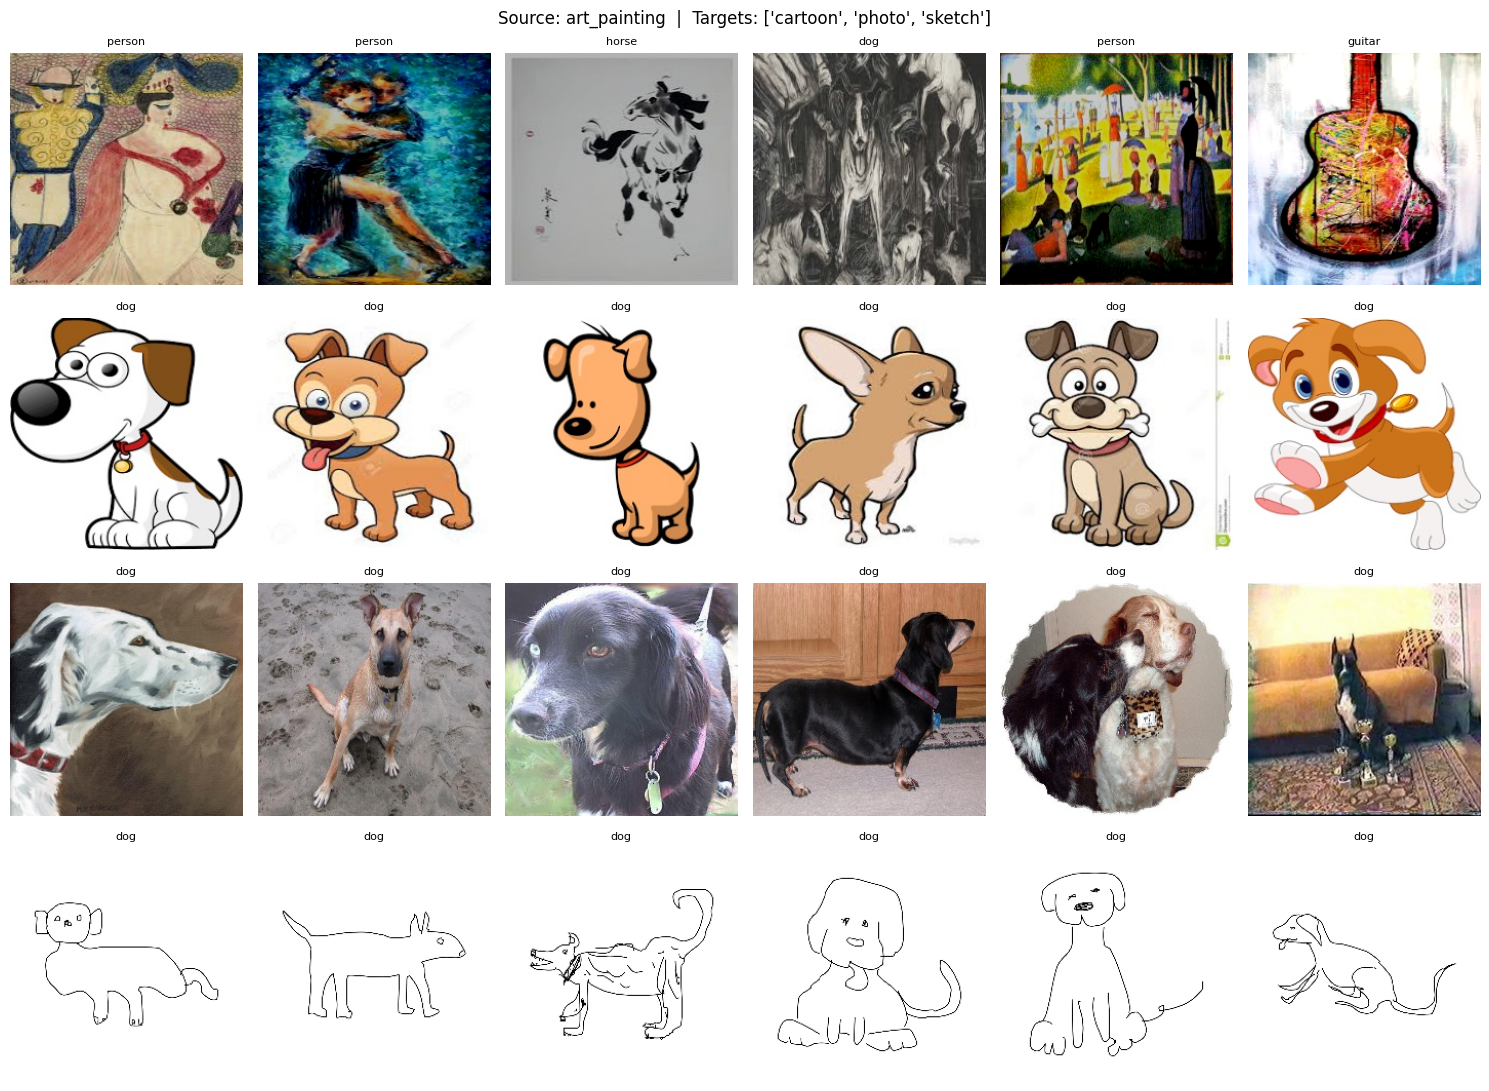

In [5]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

N = 6  # images per row
n_rows = 1 + len(TARGET_DOMAINS)
fig, axes = plt.subplots(n_rows, N, figsize=(N * 2.5, n_rows * 2.8))

# Source row
src_imgs, src_labels = next(iter(source_train_loader))
for i in range(N):
    axes[0, i].imshow(denormalize(src_imgs[i]).permute(1, 2, 0))
    axes[0, i].set_title(CLASS_NAMES[src_labels[i].item()], fontsize=8)
    axes[0, i].axis("off")
axes[0, 0].set_ylabel(SOURCE_DOMAIN, fontsize=9, rotation=90, labelpad=4)

# Target rows
for row, (d, loader) in enumerate(target_val_loaders.items(), start=1):
    imgs, labels = next(iter(loader))
    for i in range(N):
        axes[row, i].imshow(denormalize(imgs[i]).permute(1, 2, 0))
        axes[row, i].set_title(CLASS_NAMES[labels[i].item()], fontsize=8)
        axes[row, i].axis("off")
    axes[row, 0].set_ylabel(d, fontsize=9, rotation=90, labelpad=4)

plt.suptitle(f"Source: {SOURCE_DOMAIN}  |  Targets: {TARGET_DOMAINS}", fontsize=12)
plt.tight_layout()
plt.show()

# Models

## Feature Extractor — Pretrained ResNet-50

In [6]:
class FeatureExtractor(nn.Module):
    def __init__(self, freeze_until_layer4=True):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # (B, 2048, 1, 1)

        if freeze_until_layer4:
            for name, param in resnet.named_parameters():
                if not name.startswith("layer4"):
                    param.requires_grad = False

    def forward(self, x):
        return self.backbone(x).view(x.size(0), -1)  # (B, 2048)

## Label Classifier

In [7]:
class LabelClassifier(nn.Module):
    def __init__(self, feat_dim=2048, num_classes=7):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.fc(x)

## Domain Discriminator

In [8]:
class DomainDiscriminator(nn.Module):
    def __init__(self, feat_dim=2048):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

## Gradient Reversal Layer

In [9]:
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)   # identity in forward

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None   # negated in backward

def grad_reverse(x, alpha=1.0):
    return GradReverse.apply(x, alpha)

## Initialise

In [10]:
F = FeatureExtractor(freeze_until_layer4=True).to(device)
C = LabelClassifier(feat_dim=2048, num_classes=NUM_CLASSES).to(device)
D = DomainDiscriminator(feat_dim=2048).to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"F trainable params : {count_params(F):,}")
print(f"C trainable params : {count_params(C):,}")
print(f"D trainable params : {count_params(D):,}")

F trainable params : 14,964,736
C trainable params : 1,052,679
D trainable params : 1,049,601


## Losses and Optimizers

In [11]:
criterion_class  = nn.CrossEntropyLoss()
criterion_domain = nn.BCELoss()

optimizer_FC = optim.Adam(
    list(F.parameters()) + list(C.parameters()), lr=LR, weight_decay=1e-4
)
optimizer_D  = optim.Adam(D.parameters(), lr=LR, weight_decay=1e-4)

# Training

## Alpha Schedule

$$\alpha_p = \frac{2}{1 + e^{-10p}} - 1, \quad p \in [0, 1]$$

GRL strength ramps from **0 → 1** so the adversary does not destabilise early feature learning.

In [12]:
def get_alpha(step, total_steps):
    p = step / total_steps
    return 2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0

In [13]:
total_steps = EPOCHS * len(source_train_loader)
global_step = 0

history = {"class_loss": [], "domain_loss": []}

for epoch in range(1, EPOCHS + 1):
    F.train(); C.train(); D.train()

    # Re-create target iterator each epoch (combined pool)
    tgt_iter = iter(target_train_loader)
    epoch_class_loss  = 0.0
    epoch_domain_loss = 0.0

    loop = tqdm(
        enumerate(source_train_loader),
        total=len(source_train_loader),
        desc=f"Epoch {epoch}/{EPOCHS}"
    )

    for i, (x_s, y_s) in loop:
        x_s, y_s = x_s.to(device), y_s.to(device)

        try:
            x_t, _ = next(tgt_iter)
        except StopIteration:
            tgt_iter = iter(target_train_loader)
            x_t, _ = next(tgt_iter)
        x_t = x_t.to(device)

        alpha = get_alpha(global_step, total_steps)
        global_step += 1

        # ── Forward ──────────────────────────────────────────────────────────
        x    = torch.cat([x_s, x_t], dim=0)
        feat = F(x)

        # Classification: source only
        loss_class = criterion_class(C(feat[:x_s.size(0)]), y_s)

        # Domain: source=1, combined-target=0
        feat_rev = grad_reverse(feat, alpha)
        domain_labels = torch.cat([
            torch.ones (x_s.size(0), 1, device=device),
            torch.zeros(x_t.size(0), 1, device=device)
        ], dim=0)
        loss_domain = criterion_domain(D(feat_rev), domain_labels)

        # ── Update ───────────────────────────────────────────────────────────
        loss = loss_class + loss_domain
        optimizer_FC.zero_grad()
        optimizer_D.zero_grad()
        loss.backward()
        optimizer_FC.step()
        optimizer_D.step()

        epoch_class_loss  += loss_class.item()
        epoch_domain_loss += loss_domain.item()

        if i % 5 == 0:
            loop.set_postfix(
                ClassLoss  = f"{loss_class.item():.3f}",
                DomainLoss = f"{loss_domain.item():.3f}",
                alpha      = f"{alpha:.3f}"
            )

    n = len(source_train_loader)
    history["class_loss"].append(epoch_class_loss / n)
    history["domain_loss"].append(epoch_domain_loss / n)

Epoch 30/30: 100%|██████████| 52/52 [00:21<00:00,  2.40it/s, ClassLoss=0.000, DomainLoss=0.711, alpha=1.000]


## Training Curves

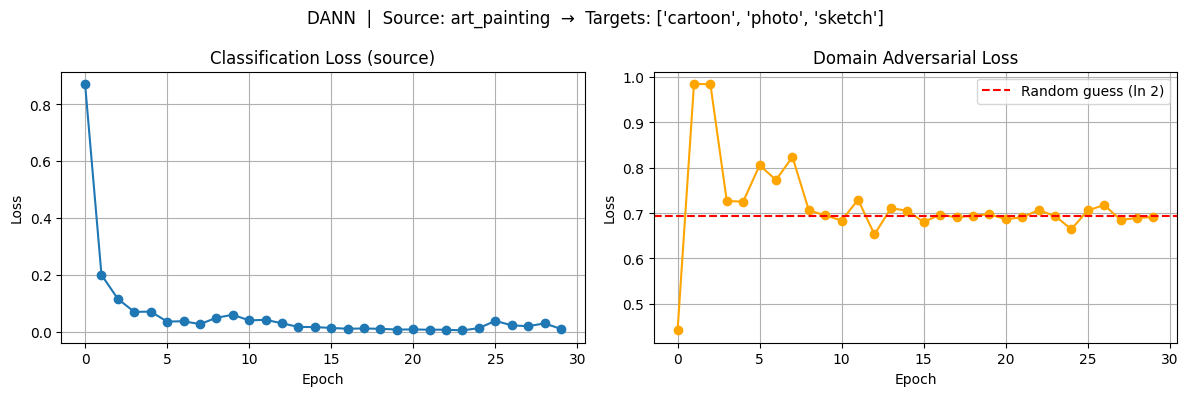

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["class_loss"], marker="o")
axes[0].set_title("Classification Loss (source)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(history["domain_loss"], marker="o", color="orange")
axes[1].axhline(y=0.693, color="red", linestyle="--", label="Random guess (ln 2)")
axes[1].set_title("Domain Adversarial Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.suptitle(
    f"DANN  |  Source: {SOURCE_DOMAIN}  →  Targets: {TARGET_DOMAINS}", fontsize=12
)
plt.tight_layout()
plt.show()

# Evaluate

We report accuracy on:
- **Source val** — sanity-check that the classifier still works on source
- **Each target domain separately** — to see which domains benefit most from adaptation

In [15]:
def evaluate(F, C, loader, name):
    F.eval(); C.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = C(F(x)).argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    acc = 100.0 * correct / total
    print(f"  {name:25s}: {acc:.2f}%")
    return acc

print("=" * 48)
print("Accuracy Report")
print("=" * 48)
src_acc = evaluate(F, C, source_val_loader, f"{SOURCE_DOMAIN} (source val)")
print("-" * 48)
tgt_accs = {}
for d, loader in target_val_loaders.items():
    tgt_accs[d] = evaluate(F, C, loader, f"{d} (target)")
print("=" * 48)
print(f"  Mean target accuracy        : {np.mean(list(tgt_accs.values())):.2f}%")

Accuracy Report
  art_painting (source val): 91.44%
------------------------------------------------
  cartoon (target)         : 61.39%
  photo (target)           : 95.81%
  sketch (target)          : 51.74%
  Mean target accuracy        : 69.65%


## Per-Domain Accuracy Bar Chart

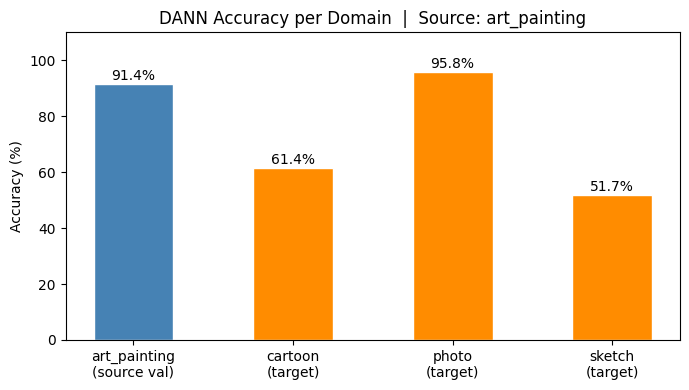

In [16]:
domains = [f"{SOURCE_DOMAIN}\n(source val)"] + [f"{d}\n(target)" for d in TARGET_DOMAINS]
accs    = [src_acc] + [tgt_accs[d] for d in TARGET_DOMAINS]
colors  = ["steelblue"] + ["darkorange"] * len(TARGET_DOMAINS)

plt.figure(figsize=(7, 4))
bars = plt.bar(domains, accs, color=colors, edgecolor="white", width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=10)
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title(f"DANN Accuracy per Domain  |  Source: {SOURCE_DOMAIN}")
plt.tight_layout()
plt.show()

## Confusion Matrices — All Target Domains

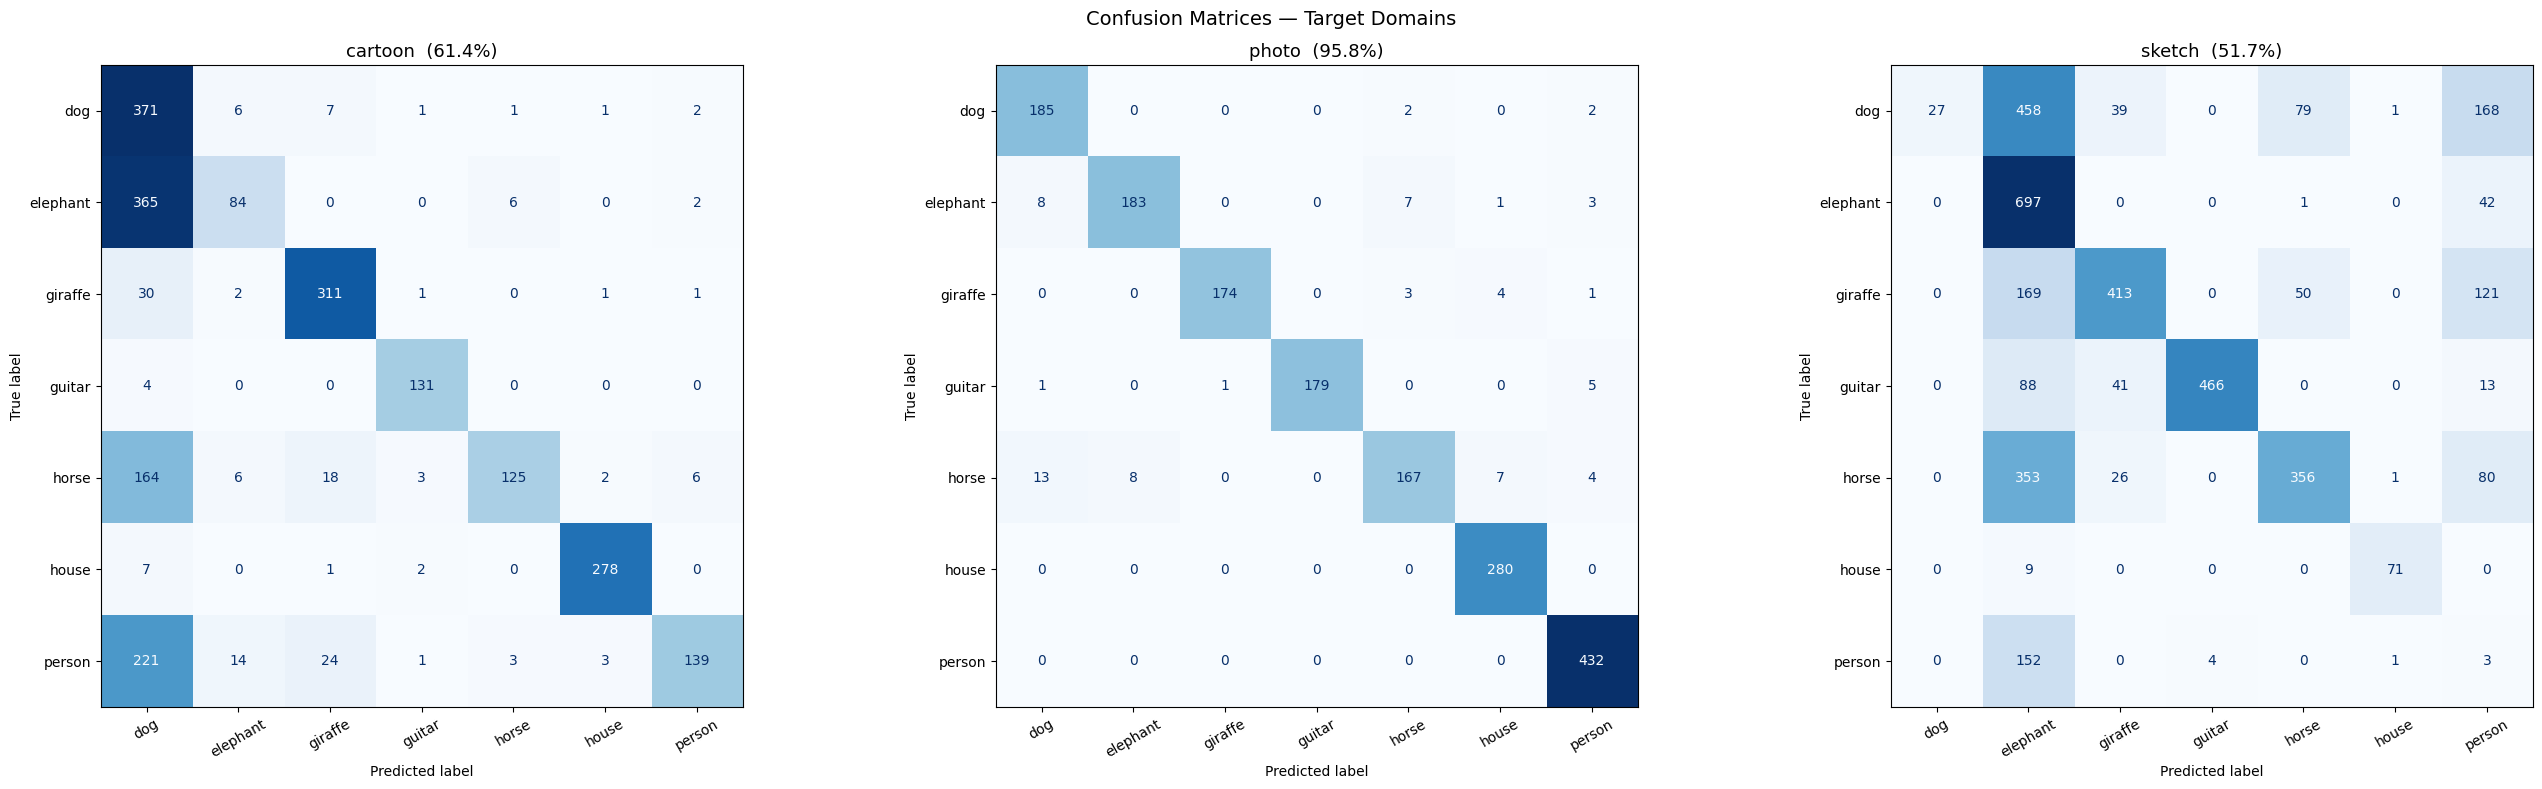

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

n_targets = len(TARGET_DOMAINS)
fig, axes = plt.subplots(1, n_targets, figsize=(9 * n_targets, 8))
if n_targets == 1:
    axes = [axes]   # ensure iterable

F.eval(); C.eval()
for ax, (d, loader) in zip(axes, target_val_loaders.items()):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            pred = C(F(x.to(device))).argmax(dim=1).cpu()
            all_preds.append(pred)
            all_labels.append(y)
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{d}  ({tgt_accs[d]:.1f}%)", fontsize=13)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Confusion Matrices — Target Domains", fontsize=14)
plt.tight_layout()
plt.show()